Francesca Conti - francesca.conti22@studio.unibo.it (Student ID: 111)

Matteo Preda - matteo.preda@studio.unibo.it (Student ID: 112)


# **Product Recognition of Books**

## Image Processing and Computer Vision - Assignment Module \#1

Contacts:

- Prof. Giuseppe Lisanti -> giuseppe.lisanti@unibo.it
- Prof. Samuele Salti -> samuele.salti@unibo.it
- Alex Costanzino -> alex.costanzino@unibo.it
- Francesco Ballerini -> francesco.ballerini4@unibo.it


Computer vision-based object detection techniques can be applied in library or bookstore settings to build a system that identifies books on shelves.

Such a system could assist in:

- Helping visually impaired users locate books by title/author;
- Automating inventory management (e.g., detecting misplaced or out-of-stock books);
- Enabling faster book retrieval by recognizing spine text or cover designs.


## Task

Develop a computer vision system that, given a reference image for each book, is able to identify such book from one picture of a shelf.

<figure>
<a href="https://ibb.co/pvLVjbM5"><img src="https://i.ibb.co/svVx9bNz/example.png" alt="example" border="0"></a>
</figure>

For each type of product displayed on the shelf, the system should compute a bounding box aligned with the book spine or cover and report:

1. Number of instances;
1. Dimension of each instance (area in pixel of the bounding box that encloses each one of them);
1. Position in the image reference system of each instance (four corners of the bounding box that enclose them);
1. Overlay of the bounding boxes on the scene images.

<font color="red"><b>Each step of this assignment must be solved using traditional computer vision techniques.</b></font>

#### Example of expected output

```
Book 0 - 2 instance(s) found:
  Instance 1 {top_left: (100,200), top_right: (110, 220), bottom_left: (10, 202), bottom_right: (10, 208), area: 230px}
  Instance 2 {top_left: (90,310), top_right: (95, 340), bottom_left: (24, 205), bottom_right: (23, 234), area: 205px}
Book 1 – 1 instance(s) found:
.
.
.
```


## Data

Two folders of images are provided:

- **Models**: contains one reference image for each product that the system should be able to identify;
- **Scenes**: contains different shelve pictures to test the developed algorithm in different scenarios.


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

!cp -r /content/drive/MyDrive/AssignmentsIPCV/dataset.zip ./
!unzip dataset.zip

In [1]:
import cv2
import os
import matplotlib.pyplot as plt
import numpy as np
from tqdm.auto import tqdm

# Set latex font for plots cmu
plt.rcParams["font.family"] = "cmr10"
plt.rcParams["font.size"] = 16

c:\Users\franc\AppData\Local\Programs\Python\Python312\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
MODELS_FOLDER = "./dataset/models"
SCENES_FOLDER = "./dataset/scenes"

# read all the images inside all models and scene
models_images = []
scenes_images = []

for folder, image_list, image_name, image_ext in [
    (MODELS_FOLDER, models_images, "model", "png"),
    (SCENES_FOLDER, scenes_images, "scene", "jpg"),
]:
    num_images = len(
        [name for name in os.listdir(folder) if name.startswith(image_name)]
    )
    for i in range(num_images):
        image_list.append(
            cv2.imread(os.path.join(folder, f"{image_name}_{i}.{image_ext}"))
        )

# Methodology

The proposed solution is based on the extraction and matching of SIFT features between the model images and the scene images. The main steps of the algorithm are as follows:

1. Preprocess the images to enhance SIFT performance (Gaussian blur and histogram equalization). [**Discarded at the end because it did not improve performance**]
2. Extract SIFT keypoints and descriptors from both model and scene images (SIFT is a robust feature descriptor).
3. Match the descriptors using a $k$-NN matcher with $k=5$ (we did not use $k=2$ because a higher $k$ helps in scenes with multiple instances of the same model).
4. Apply Lowe's ratio test to filter out weak matches.
5. We estimate an affine transformation using RANSAC to robustly estimate the mapping between the model and scene keypoints. (**We did not use Homography estimation because the books are mostly planar objects and the perspective distortion is not significant in our dataset. In this way we can inject an inductive bias towards the expected book layout.**)
6. Use the estimated affine transformation to project the corners of the model image onto the scene image, obtaining the bounding boxes for each detected book instance.
7. Draw a black bounding box using the projected corners and repeat the process for each model image on the scene image. (**This is done to avoid detecting the same instance multiple times.**)


In [ ]:
def instance_detect(
    scene_img,
    model_img,
    preprocess=None,
    plot_matches: bool = True,
    plot_rectangle: bool = True,
    plot_descriptors: bool = False,
    debug: bool = False,
):
    """
    Given a scene image and a model image, detect a single instance of the model in the scene.
    """

    # SIFT only works on a single channel (grayscale) images
    model_gray = cv2.cvtColor(model_img, cv2.COLOR_BGR2GRAY)
    scene_gray = cv2.cvtColor(scene_img, cv2.COLOR_BGR2GRAY)

    if preprocess is not None:
        model_gray = preprocess(model_gray)
        scene_gray = preprocess(scene_gray)

    # Define and compute SIFT keypoints and descriptors
    sift = cv2.SIFT_create(
        nfeatures=0,
        nOctaveLayers=7,  # Increased to capture more details
        contrastThreshold=0.02,  # Lowered to detect more keypoints
        edgeThreshold=10,
        sigma=1.2,
    )
    model_keypoints, des_model = sift.detectAndCompute(model_gray, None)
    scene_keypoints, des_scene = sift.detectAndCompute(scene_gray, None)

    if plot_descriptors:
        model_img_kp = cv2.drawKeypoints(
            model_img.copy(),
            model_keypoints,
            None,
            flags=cv2.DRAW_MATCHES_FLAGS_DRAW_RICH_KEYPOINTS,
        )
        scene_img_kp = cv2.drawKeypoints(
            scene_img.copy(),
            scene_keypoints,
            None,
            flags=cv2.DRAW_MATCHES_FLAGS_DRAW_RICH_KEYPOINTS,
        )

        plt.figure(figsize=(20, 10))
        plt.subplot(1, 2, 1)
        plt.imshow(cv2.cvtColor(model_img_kp, cv2.COLOR_BGR2RGB))
        plt.title("Model Keypoints")
        plt.axis("off")

        plt.subplot(1, 2, 2)
        plt.imshow(cv2.cvtColor(scene_img_kp, cv2.COLOR_BGR2RGB))
        plt.title("Scene Keypoints")
        plt.axis("off")
        plt.show()

    # Match descriptors using Brute Force Matcher
    bf = cv2.BFMatcher(cv2.NORM_L2)
    knn_matches = bf.knnMatch(des_model, des_scene, k=5)

    # Filter out the good matches
    good_matches = []
    for matches in knn_matches:
        for i in range(len(matches) - 1):
            if matches[i].distance < 0.6 * matches[i + 1].distance:  # Lowe's ratio test
                good_matches.append(matches[i])

    if plot_matches:
        # Plot the distribution of distances
        distances = [m.distance for m in good_matches]
        plt.figure(figsize=(10, 5))
        plt.hist(distances, bins=30, color="blue", alpha=0.7)
        plt.title("Distribution of Descriptor Distances for Good Matches")
        plt.xlabel("Distance")
        plt.ylabel("Frequency")
        plt.grid()
        plt.show()

    if plot_matches:
        plt.figure(figsize=(20, 10))
        img_matches = cv2.drawMatches(
            model_img.copy(),
            model_keypoints,
            scene_img.copy(),
            scene_keypoints,
            good_matches,
            None,
            flags=cv2.DrawMatchesFlags_NOT_DRAW_SINGLE_POINTS,
        )
        plt.subplot(1, 2, 1)
        plt.imshow(cv2.cvtColor(img_matches, cv2.COLOR_BGR2RGB))
        plt.title("SIFT Matches")
        plt.show()

    model_matching_keypoints = np.float32(
        [model_keypoints[m.queryIdx].pt for m in good_matches]
    ).reshape(-1, 1, 2)
    scene_matching_keypoints = np.float32(
        [scene_keypoints[m.trainIdx].pt for m in good_matches]
    ).reshape(-1, 1, 2)

    # We empirically found that at least 5 matches are needed to compute a reliable homography
    if len(good_matches) < 5:
        if debug:
            print("Not enough matches found.")
        return [[[0, 0], [0, 0], [0, 0], [0, 0]]]

    # We do not use findHomography because we use the inductive bias that the object is planar and we can use
    # affine transformations only (no perspective distortion)
    M, inliers = cv2.estimateAffinePartial2D(
        model_matching_keypoints,
        scene_matching_keypoints,
        method=cv2.RANSAC,
        ransacReprojThreshold=5.0,
    )

    # Convert affine matrix to homography matrix
    H = np.vstack([M, [0, 0, 1]])

    inlier_mask = inliers.ravel().tolist()
    num_inliers = sum(inlier_mask)

    if debug:
        print(f"RANSAC inliers: {num_inliers} / {len(good_matches)}")

    # We empirically found that at least 1/3 of the matches should be inliers to consider a valid detection
    if num_inliers / len(good_matches) < 1 / 3 or num_inliers < 5:
        if debug:
            print("Not enough inliers after RANSAC.")
        return [[[0, 0], [0, 0], [0, 0], [0, 0]]]

    # Get the corners of the model image
    model_corners = np.float32(
        [
            [0, 0],
            [model_img.shape[1], 0],
            [model_img.shape[1], model_img.shape[0]],
            [0, model_img.shape[0]],
        ]
    ).reshape(-1, 1, 2)

    if H is None:
        if debug:
            print("Homography could not be computed.")
        return [[[0, 0], [0, 0], [0, 0], [0, 0]]]

    # Transform the corners to the scene image using the homography
    scene_corners = cv2.perspectiveTransform(model_corners, H)
    if plot_rectangle:
        scene_img_with_box = scene_img.copy()
        cv2.polylines(
            scene_img_with_box,
            [np.int32(scene_corners)],
            isClosed=True,
            color=(0, 255, 0),
            thickness=5,
        )

        plt.subplot(1, 2, 2)
        plt.imshow(cv2.cvtColor(scene_img_with_box, cv2.COLOR_BGR2RGB))
        plt.title("Detected Model")
        plt.axis("off")

    plt.show()
    return scene_corners


def is_rectangle_valid(rectangle, image_shape):
    # Criterias:
    # 1. Should have 4 points
    # 2. Area should be within a certain reasonable range
    # 3. Check if the shape is roughly rectangular
    # 4. Check if the rectangle is within the image bounds

    if len(rectangle) != 4:
        return False, "Not 4 points"

    # Check area
    area = cv2.contourArea(rectangle)
    if area < 1000 or area > 100000:
        return False, "Invalid area"

    # Check ratio of area to bounding box area (extent)
    x, y, w, h = cv2.boundingRect(rectangle)
    bounding_box_area = w * h
    rectangle_area = cv2.contourArea(rectangle)
    extent = rectangle_area / bounding_box_area

    if extent < 0.5:
        return False, "Not rectangular enough"

    # Check if the rectangle is within the image bounds
    for p in rectangle:
        x, y = p[0]
        if x < 0 or x >= image_shape[1] or y < 0 < 0 or y >= image_shape[0]:
            return False, "Point out of bounds"

    return True, "Valid rectangle"

## Plotting function


In [4]:
def plot_detections(scenes_images, matches, SCENE_IDX=0):
    """
    Plot the scene image with detected models outlined and the model images with colored borders.
    """
    import cv2
    import matplotlib.pyplot as plt
    import numpy as np

    TARGET_HEIGHT = 600

    COLORS = [(255, 0, 0), (0, 255, 0), (0, 0, 255), (255, 255, 0), (0, 255, 255)]

    # Resize scene image
    h, w = scenes_images[SCENE_IDX].shape[:2]
    scale = TARGET_HEIGHT / h
    scene_resized = cv2.resize(
        scenes_images[SCENE_IDX], (int(w * scale), TARGET_HEIGHT)
    )

    # Draw polylines on resized image
    for i, (model_image, scene_corners, idx, scene_idx) in enumerate(matches):
        # Scale corners to match resized image
        scaled_corners = scene_corners * scale
        scene_resized = cv2.polylines(
            scene_resized,
            [np.int32(scaled_corners)],
            isClosed=True,
            color=COLORS[i % len(COLORS)],
            thickness=5,
        )

    plt.figure(figsize=(5 + 2 * (len(matches)), 5))

    plt.subplot(1, len(matches) + 1, 1)
    plt.imshow(cv2.cvtColor(scene_resized, cv2.COLOR_BGR2RGB))
    plt.title(f"Scene {SCENE_IDX}")
    plt.axis("off")

    # Plot each model image
    for i, (model_image, scene_corners, idx, scene_idx) in enumerate(matches):
        h, w = model_image.shape[:2]
        scale = TARGET_HEIGHT / h
        model_resized = cv2.resize(model_image, (int(w * scale), TARGET_HEIGHT))

        # Draw colored border
        cv2.polylines(
            model_resized,
            [
                np.int32(
                    [
                        [0, 0],
                        [model_resized.shape[1], 0],
                        [model_resized.shape[1], model_resized.shape[0]],
                        [0, model_resized.shape[0]],
                    ]
                )
            ],
            isClosed=True,
            color=COLORS[i % len(COLORS)],
            thickness=20,
        )

        plt.subplot(1, len(matches) + 1, i + 2)
        plt.imshow(cv2.cvtColor(model_resized, cv2.COLOR_BGR2RGB))
        plt.title(f"Model {idx}")
        plt.axis("off")

    plt.tight_layout()
    plt.show()

## Main Loop

**Note**: By setting `DEBUG = True`, you can visualize the detection and matching process to better understand and debug failing instances (this produces a lot of output, so use it only on specific scenes or models).


Processing scenes:   0%|          | 0/29 [00:00<?, ?it/s]

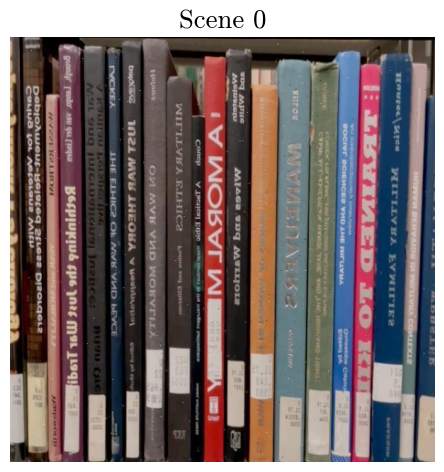

Processing scenes:   3%|▎         | 1/29 [00:07<03:29,  7.48s/it]

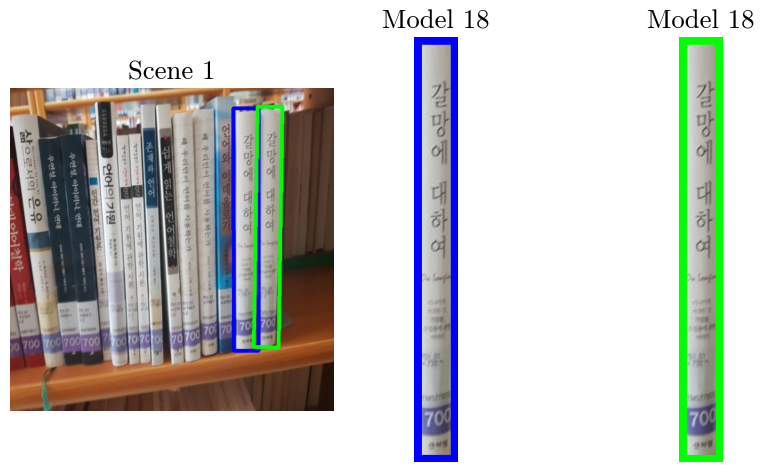

Processing scenes:   7%|▋         | 2/29 [00:13<03:02,  6.75s/it]

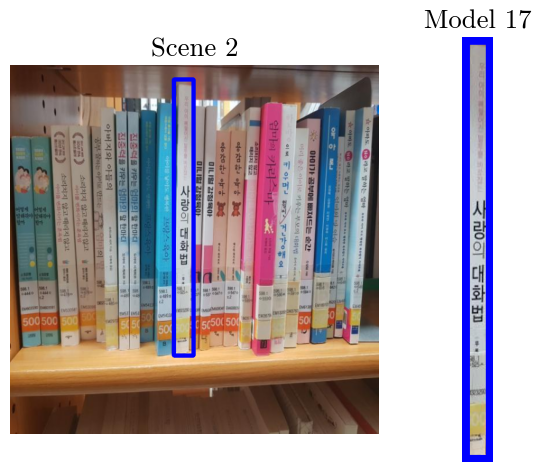

Processing scenes:  10%|█         | 3/29 [00:23<03:28,  8.01s/it]

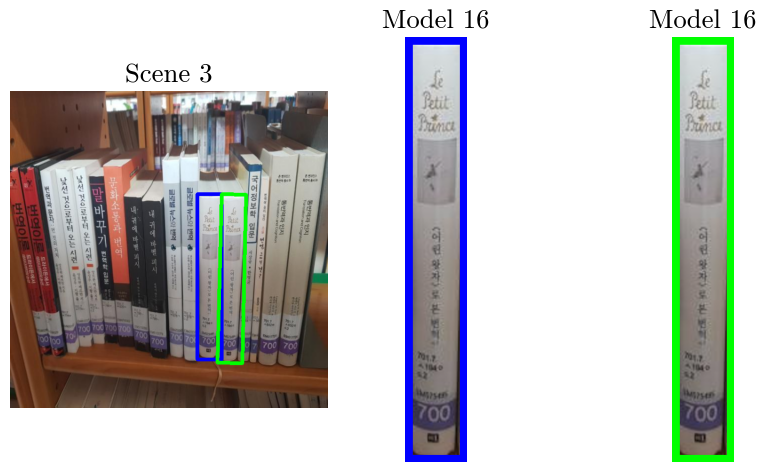

Processing scenes:  14%|█▍        | 4/29 [00:31<03:25,  8.23s/it]

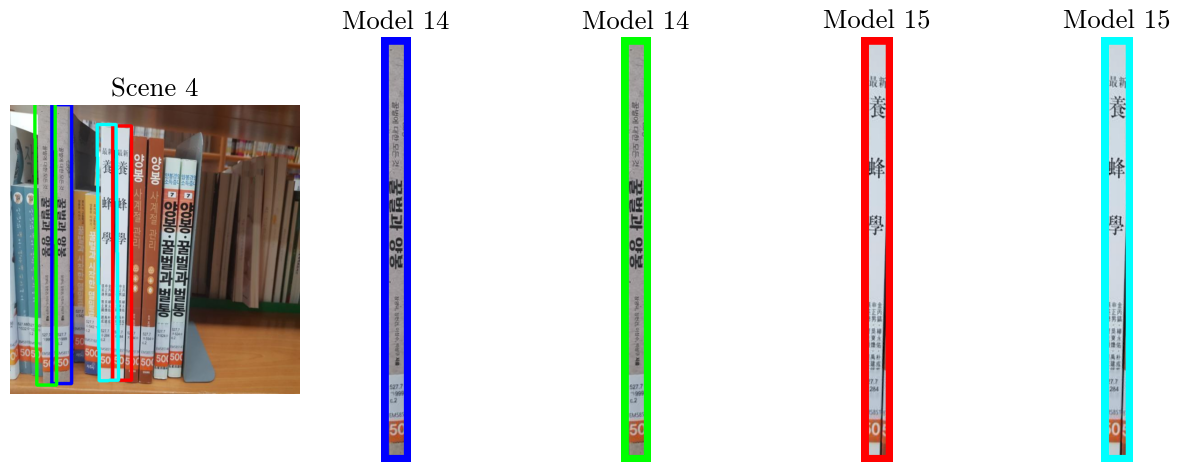

Processing scenes:  17%|█▋        | 5/29 [00:40<03:21,  8.41s/it]

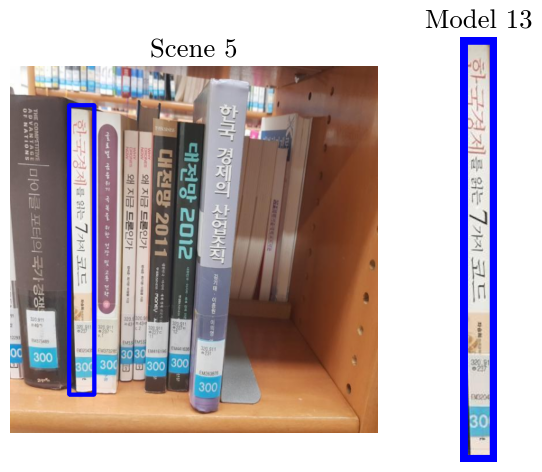

Processing scenes:  21%|██        | 6/29 [00:47<03:01,  7.90s/it]

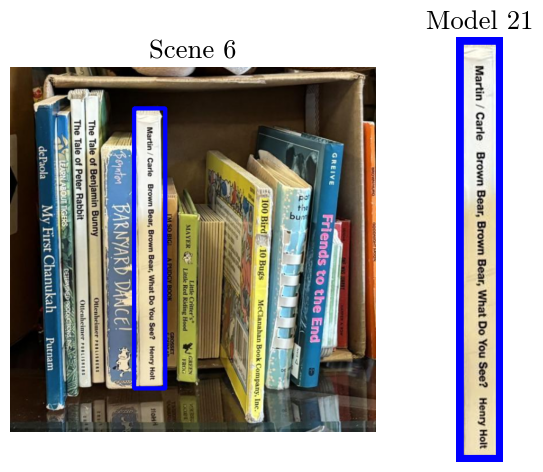

Processing scenes:  24%|██▍       | 7/29 [00:59<03:27,  9.41s/it]

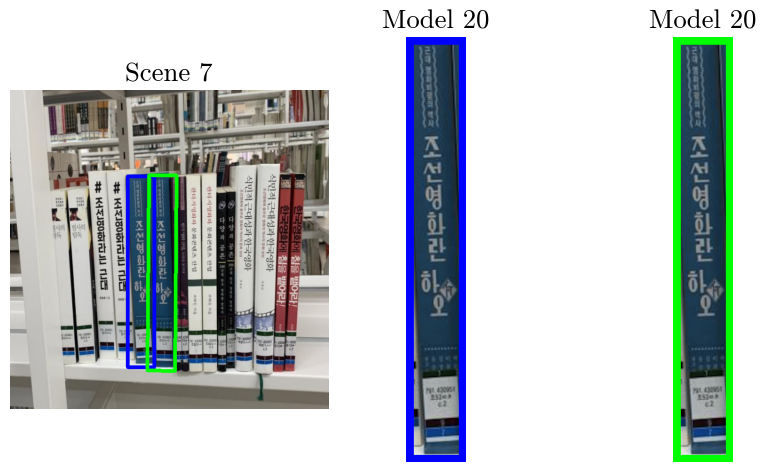

Processing scenes:  28%|██▊       | 8/29 [01:10<03:26,  9.83s/it]

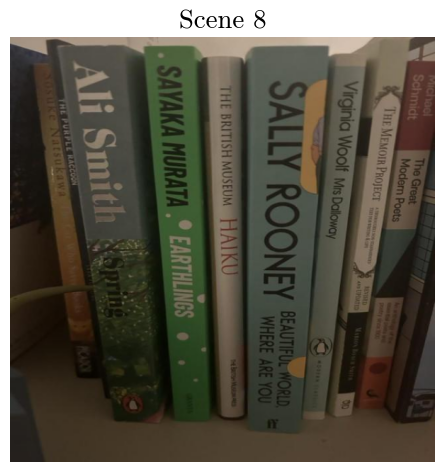

Processing scenes:  31%|███       | 9/29 [01:19<03:10,  9.53s/it]

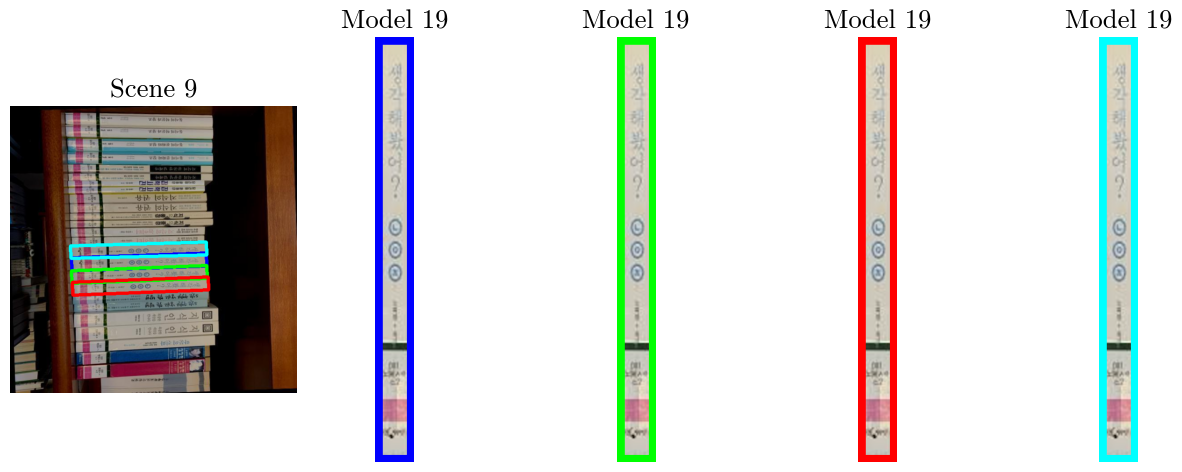

Processing scenes:  34%|███▍      | 10/29 [01:39<04:00, 12.68s/it]

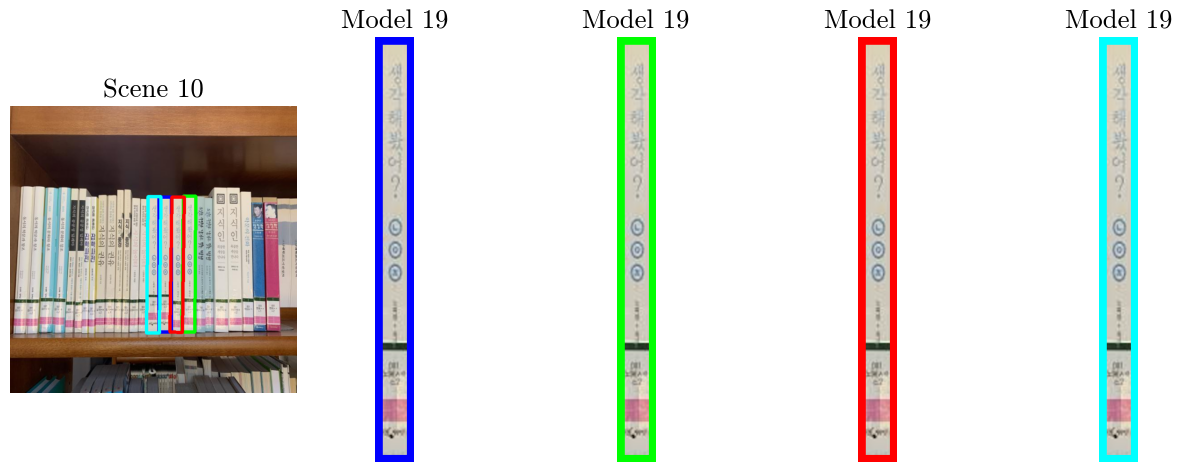

Processing scenes:  38%|███▊      | 11/29 [01:55<04:08, 13.79s/it]

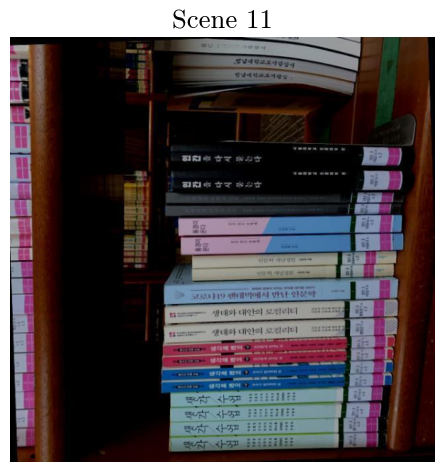

Processing scenes:  41%|████▏     | 12/29 [02:07<03:43, 13.15s/it]

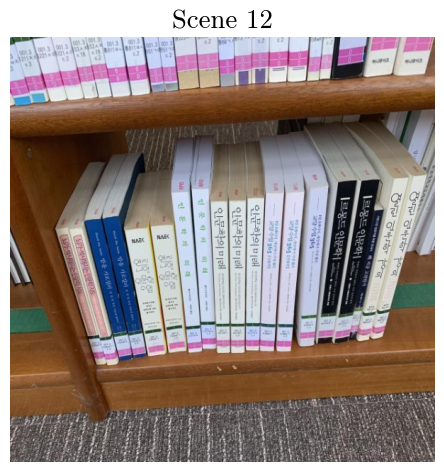

Processing scenes:  45%|████▍     | 13/29 [02:27<04:04, 15.31s/it]

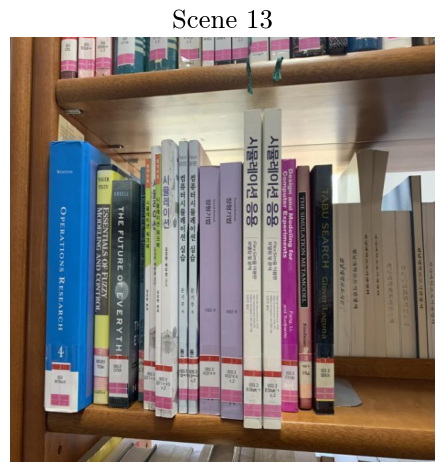

Processing scenes:  48%|████▊     | 14/29 [02:42<03:48, 15.24s/it]

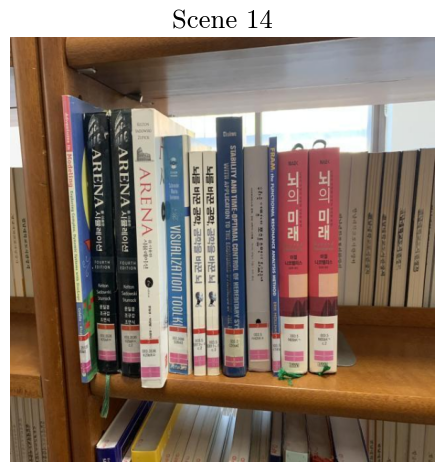

Processing scenes:  52%|█████▏    | 15/29 [02:58<03:35, 15.41s/it]

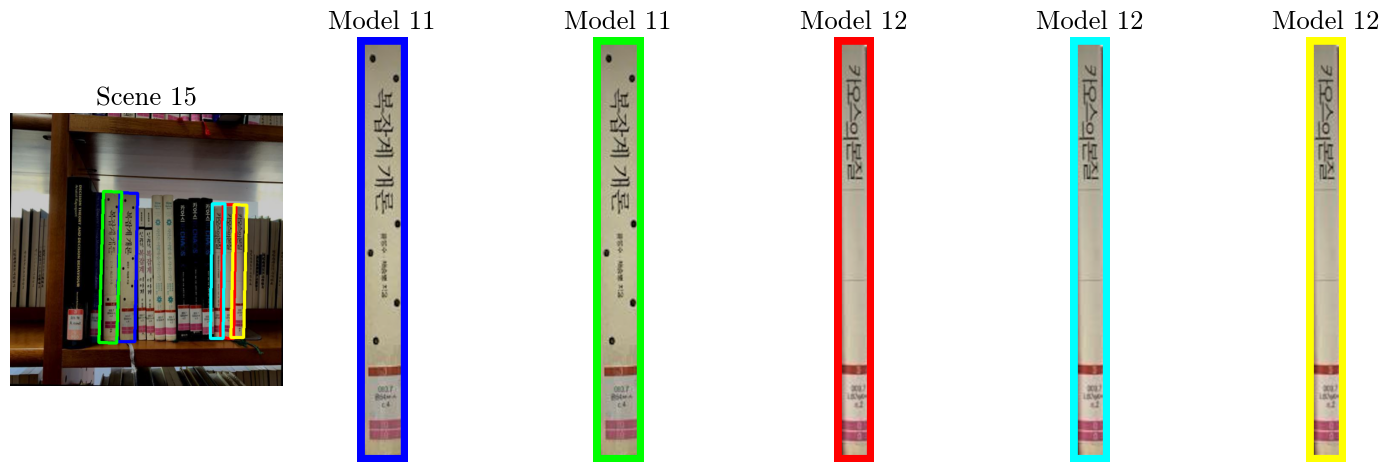

Processing scenes:  55%|█████▌    | 16/29 [03:13<03:18, 15.23s/it]

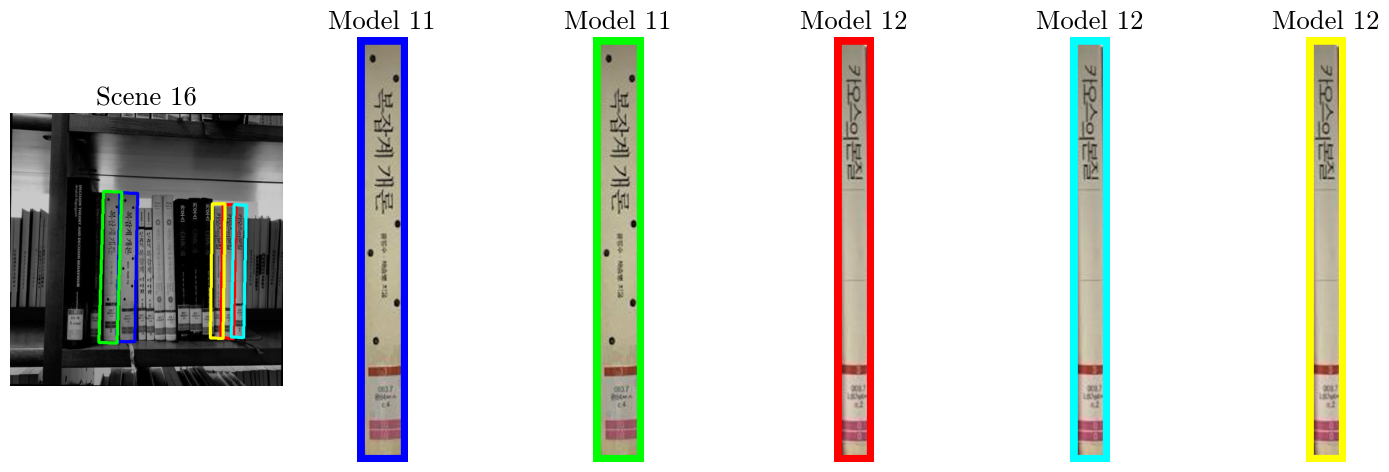

Processing scenes:  59%|█████▊    | 17/29 [03:26<02:56, 14.70s/it]

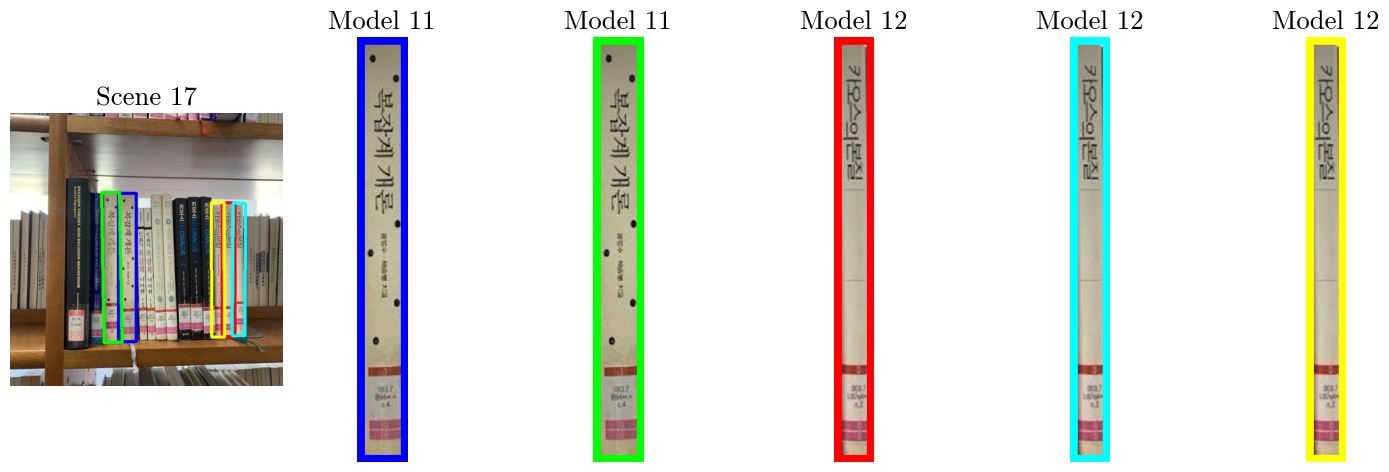

Processing scenes:  62%|██████▏   | 18/29 [03:41<02:40, 14.63s/it]

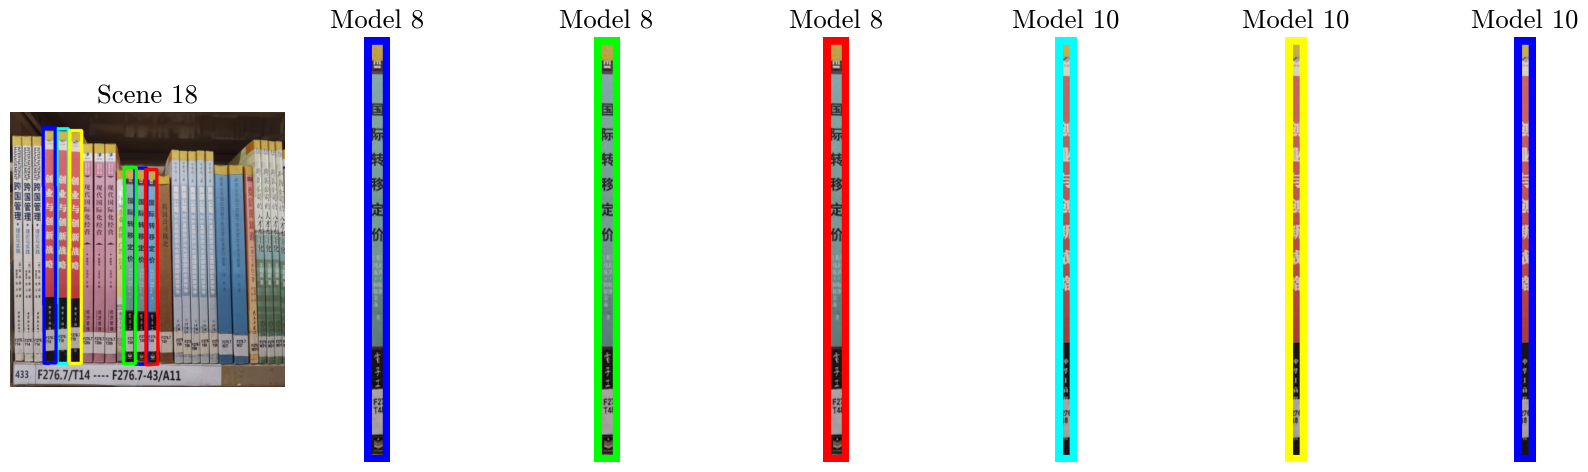

Processing scenes:  66%|██████▌   | 19/29 [04:02<02:45, 16.59s/it]

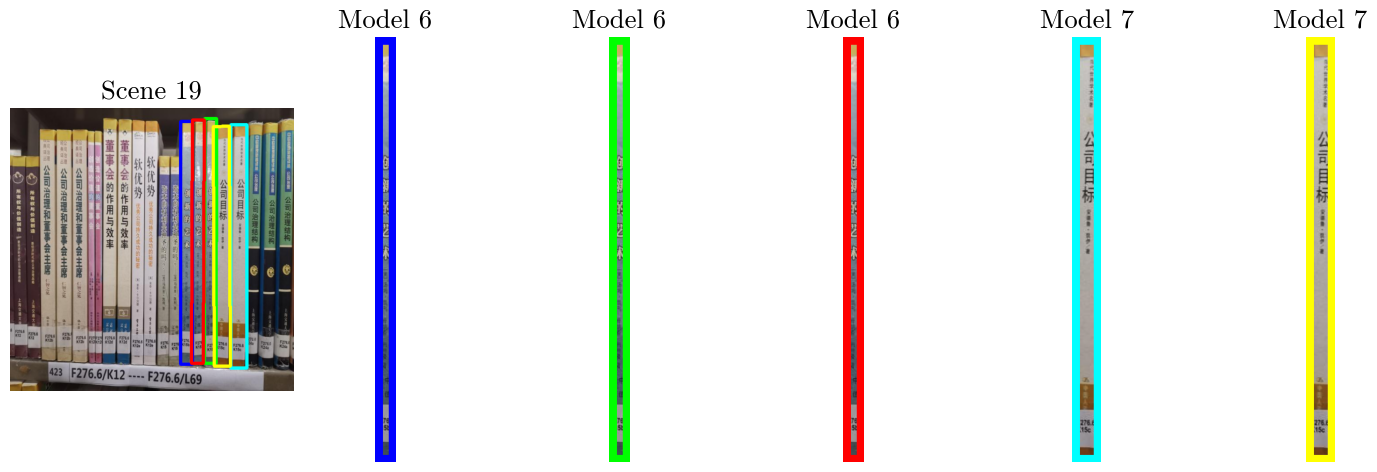

Processing scenes:  69%|██████▉   | 20/29 [04:23<02:40, 17.81s/it]

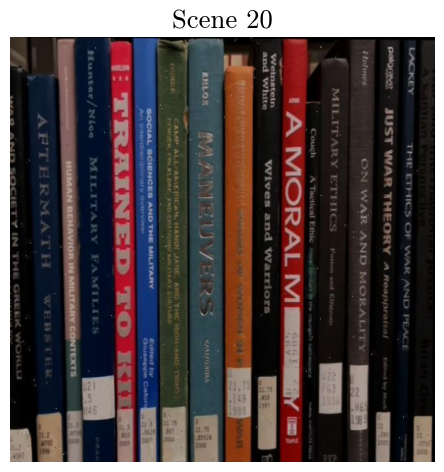

Processing scenes:  72%|███████▏  | 21/29 [04:35<02:09, 16.21s/it]

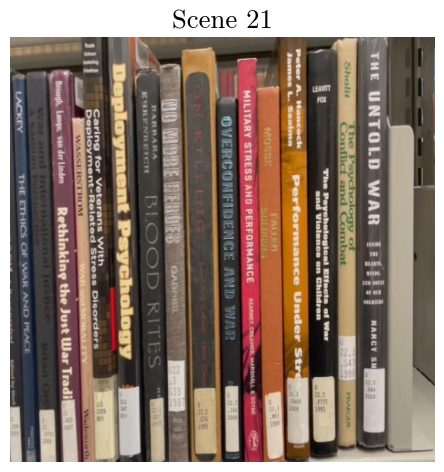

Processing scenes:  76%|███████▌  | 22/29 [04:49<01:49, 15.64s/it]

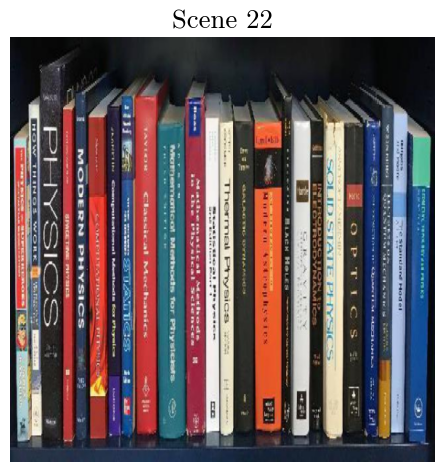

Processing scenes:  79%|███████▉  | 23/29 [05:07<01:38, 16.41s/it]

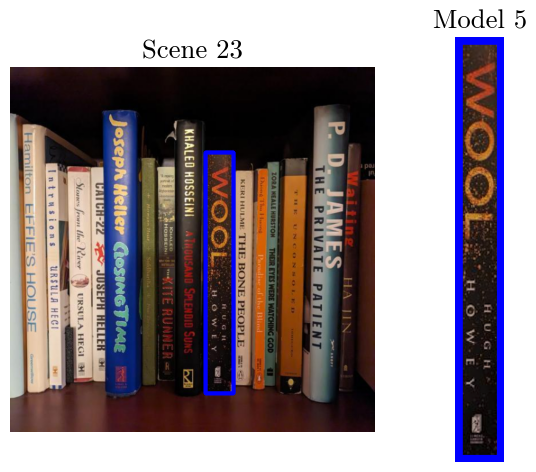

Processing scenes:  83%|████████▎ | 24/29 [05:21<01:17, 15.46s/it]

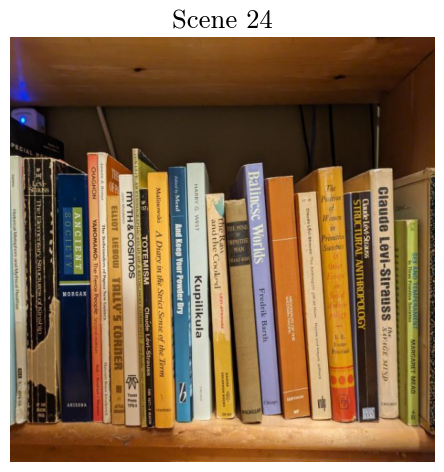

Processing scenes:  86%|████████▌ | 25/29 [05:34<00:59, 14.77s/it]

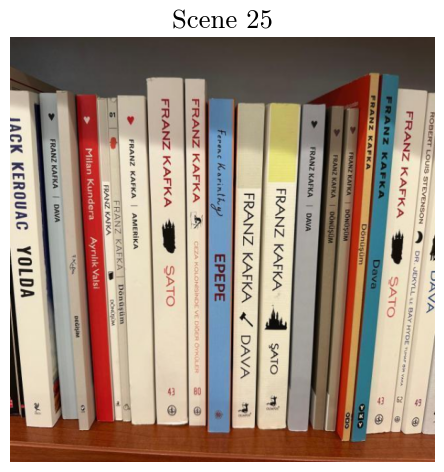

Processing scenes:  90%|████████▉ | 26/29 [05:44<00:39, 13.31s/it]

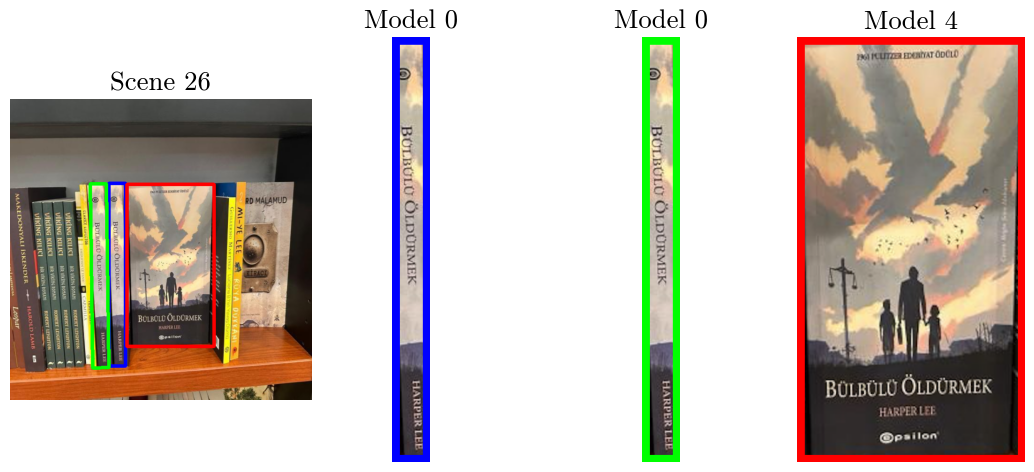

Processing scenes:  93%|█████████▎| 27/29 [05:58<00:27, 13.59s/it]

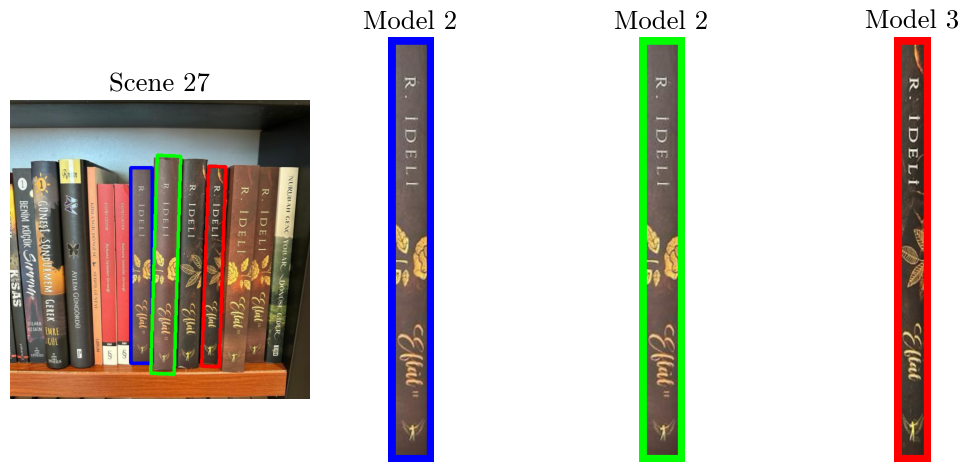

Processing scenes:  97%|█████████▋| 28/29 [06:12<00:13, 13.64s/it]

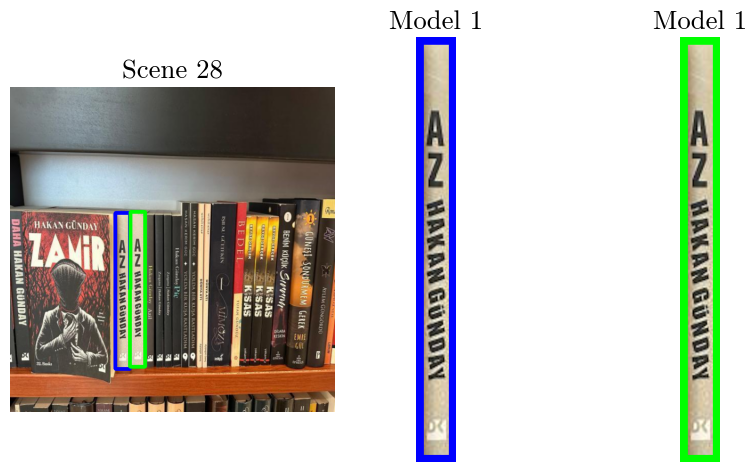

Processing scenes: 100%|██████████| 29/29 [06:28<00:00, 13.39s/it]


In [5]:
def preprocess_for_sift(gray):
    blurred = cv2.GaussianBlur(gray, (13, 13), 0)
    equalized = cv2.equalizeHist(blurred)
    return equalized


DEBUG = False
all_matches = []
for SCENE_IDX in tqdm(range(len(scenes_images)), desc="Processing scenes"):
    scenes_image = scenes_images[SCENE_IDX].copy()

    matches = []
    for idx, m in enumerate(models_images):
        model_image = m.copy()

        for i in range(10):
            scene_corners = instance_detect(
                scenes_image,
                model_image,
                preprocess=None,
                plot_matches=DEBUG,
                plot_rectangle=DEBUG,
                plot_descriptors=DEBUG,
                debug=DEBUG,
            )

            is_valid, reason = is_rectangle_valid(scene_corners, scenes_image.shape)
            if DEBUG:
                print(
                    f"Model {idx}, Iteration {i}, Valid: {is_valid}, Reason: {reason}"
                )
            if not is_valid:
                break
            # Mask the detected area in the scene image to find another instance
            mask = np.zeros(scenes_image.shape[:2], dtype=np.uint8)

            matches.append((model_image, scene_corners, idx, SCENE_IDX))
            all_matches.append((model_image, scene_corners, idx, SCENE_IDX))
            cv2.fillPoly(mask, [np.int32(scene_corners)], (255))
            scenes_image = cv2.bitwise_and(
                scenes_image, scenes_image, mask=cv2.bitwise_not(mask)
            )
    plot_detections(scenes_images, matches, SCENE_IDX=SCENE_IDX)

## Output in the required format


In [ ]:
for scene_idx in range(len(scenes_images)):
    print(f"\nDetections in scene {scene_idx}:")
    scene_matches = [m for m in all_matches if m[3] == scene_idx]
    for model_idx in range(len(models_images)):
        model_detections = [m for m in scene_matches if m[2] == model_idx]
        if len(model_detections) > 0:
            print(f"    Book {model_idx}: {len(model_detections)} instance(s) found:")
            for det_idx, det in enumerate(model_detections):
                coords = det[1].astype(int)
                print(
                    f"        Instance {det_idx}: 'top_left': {coords[0][0].tolist()}, 'bottom_right': {coords[1][0].tolist()}, 'bottom_left': {coords[2][0].tolist()}, 'top_right': {coords[3][0].tolist()},"
                )


Detections in scene 0:

Detections in scene 1:
    Book 18: 2 instance(s) found:
        Instance 0: 'top_left': [441, 42], 'bottom_right': [490, 42], 'bottom_left': [490, 520], 'top_right': [441, 520],
        Instance 1: 'top_left': [488, 38], 'bottom_right': [537, 38], 'bottom_left': [531, 515], 'top_right': [482, 514],

Detections in scene 2:
    Book 17: 1 instance(s) found:
        Instance 0: 'top_left': [283, 25], 'bottom_right': [318, 25], 'bottom_left': [318, 503], 'top_right': [283, 503],

Detections in scene 3:
    Book 16: 2 instance(s) found:
        Instance 0: 'top_left': [377, 209], 'bottom_right': [426, 209], 'bottom_left': [426, 542], 'top_right': [377, 542],
        Instance 1: 'top_left': [425, 209], 'bottom_right': [475, 210], 'bottom_left': [467, 549], 'top_right': [417, 548],

Detections in scene 4:
    Book 14: 2 instance(s) found:
        Instance 0: 'top_left': [92, 1], 'bottom_right': [135, 1], 'bottom_left': [135, 617], 'top_right': [92, 617],
        Inst

# Comments

The proposed solution based on SIFT descriptors can find most of the books in the scenes, even though it struggles with some of the most difficult ones (e.g., scene27 or scene16).
However, the proposed approach relies on many hyperparameters, that have been tuned empirically to achieve the best results on the provided dataset. We tried to implement a Grid Search but unfortunatly, it did not The main hyperparameters are:

- Detection hyperparameters:
  - SIFT parameters (e.g., number of features, contrast threshold, edge threshold, number of octaves, etc.);
- Filtering hyperparameters:
  - Lowe's ratio threshold;
  - Minimum number of inliers to accept a detection;
  - RANSAC reprojection threshold;
  - Rectangle validity criteria (e.g., area range, rectangularity extent, etc.);

Of course, the dependence on hyperparameters can lead to overfitting on the provided dataset, and the performance of the proposed approach may degrade on different datasets or real-world scenarios.
The hyperparameters search was not easy, because chaging one hyperparameter to fix a certain model-scene pair could lead to worse performance on other pairs.


## Evaluation criteria

1. **Clarity and conciseness**. Present your work in a readable way: format your code and comment every important step;

2. **Procedural correctness**. There are several ways to solve the assignment. Design your own sound approach and justify every decision you make;

3. **Correctness of results**. Try to solve as many instances as possible. You should be able to solve all the instances of the assignment, however, a thoroughly justified and sound procedure with a lower number of solved instances will be valued **more** than a poorly designed and justified approach that solves more or all instances.
